First 5 rows:
   CustomerID  Age  Annual Income  Spending Score
0           1   19             15              39
1           2   21             15              81
2           3   20             16               6
3           4   23             16              77
4           5   31             17              40

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CustomerID      50 non-null     int64
 1   Age             50 non-null     int64
 2   Annual Income   50 non-null     int64
 3   Spending Score  50 non-null     int64
dtypes: int64(4)
memory usage: 1.7 KB
None

Missing values:
CustomerID        0
Age               0
Annual Income     0
Spending Score    0
dtype: int64

Shape after cleaning: (50, 4)


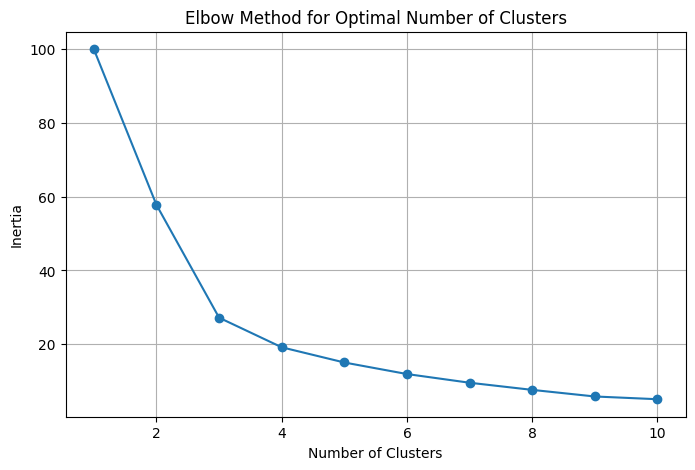


Cluster counts:
Cluster
2    14
0     9
4     9
3     9
1     9
Name: count, dtype: int64


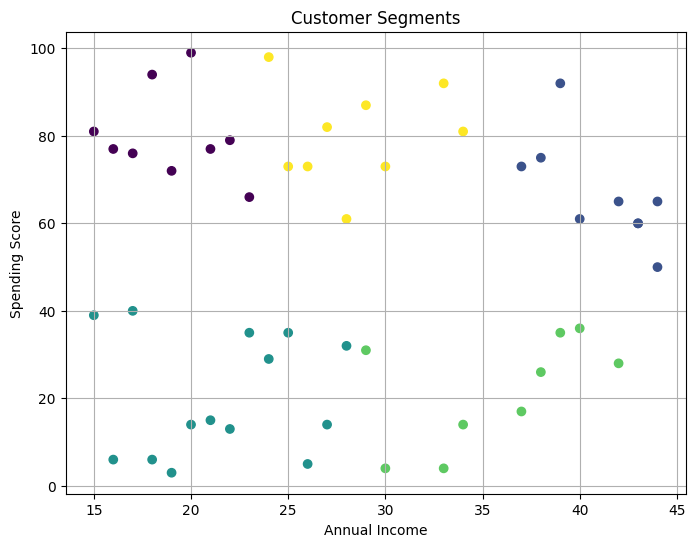


Cluster summary:
         Annual Income  Spending Score
Cluster                               
0            19.000000       80.111111
1            41.111111       66.777778
2            21.500000       20.428571
3            35.777778       21.666667
4            28.444444       80.000000

Files saved successfully:
- customer_segments_output.csv
- cluster_summary.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Load dataset
# -----------------------------
file_path = "dataset.csv"
df = pd.read_csv(file_path)

print("First 5 rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

# -----------------------------
# 2. Clean dataset
# -----------------------------
# Remove duplicate rows
df = df.drop_duplicates()

# Drop rows with missing values
df = df.dropna()

print("\nShape after cleaning:", df.shape)

# -----------------------------
# 3. Select features for clustering
# -----------------------------

features = df[["Annual Income", "Spending Score"]]

# Scale the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# -----------------------------
# 4. Find best number of clusters using elbow method
# -----------------------------
inertia = []
k_range = range(1, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(scaled_features)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# -----------------------------
# 5. Train KMeans model
# -----------------------------
# You can change n_clusters after checking the elbow chart
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(scaled_features)

print("\nCluster counts:")
print(df["Cluster"].value_counts())

# -----------------------------
# 6. Visualize clusters
# -----------------------------
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df["Annual Income"],
    df["Spending Score"],
    c=df["Cluster"]
)

plt.title("Customer Segments")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.grid(True)
plt.show()

# -----------------------------
# 7. Cluster summary
# -----------------------------
cluster_summary = df.groupby("Cluster")[["Annual Income", "Spending Score"]].mean()
print("\nCluster summary:")
print(cluster_summary)

# -----------------------------
# 8. Save results
# -----------------------------
df.to_csv("customer_segments_output.csv", index=False)
cluster_summary.to_csv("cluster_summary.csv")

print("\nFiles saved successfully:")
print("- customer_segments_output.csv")
print("- cluster_summary.csv")

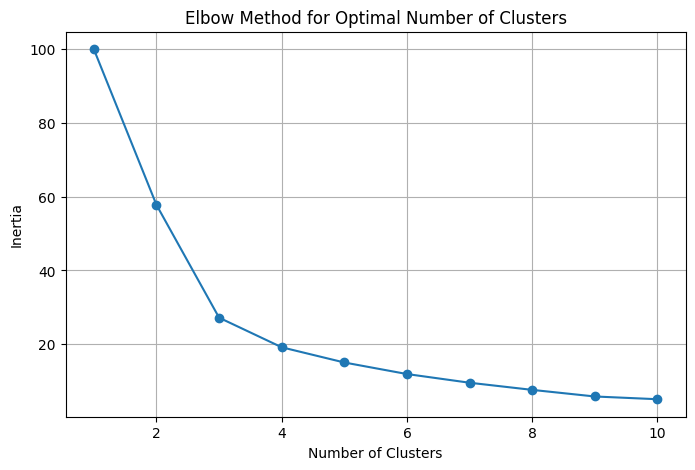

In [2]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.savefig("elbow_method.png", bbox_inches="tight")
plt.show()

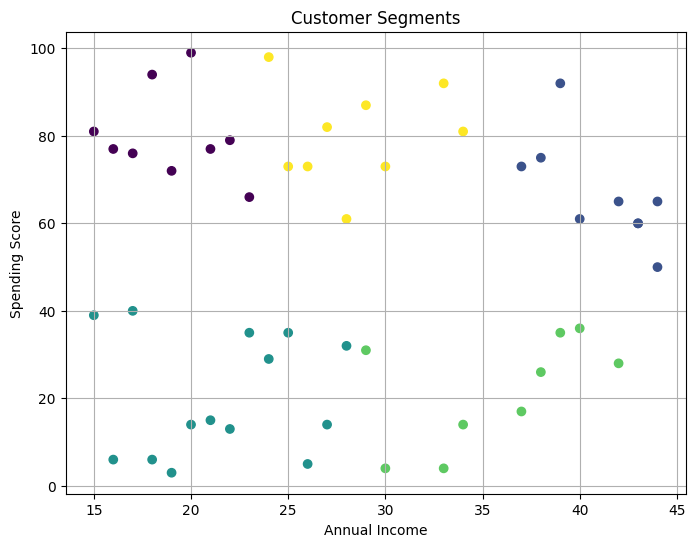

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df["Annual Income"],
    df["Spending Score"],
    c=df["Cluster"]
)
plt.title("Customer Segments")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.grid(True)
plt.savefig("customer_segments.png", bbox_inches="tight")
plt.show()